# Fase 2a — Ecuacion de onda: Sarta uniforme

**Ecuacion de Gibbs** con amortiguamiento:

$$\frac{\partial^2 u}{\partial t^2} = a^2 \frac{\partial^2 u}{\partial x^2} - c \frac{\partial u}{\partial t}$$

**Esquema leapfrog** (diferencias finitas explicitas, orden 2):

$$u_i^{n+1} = 2u_i^n - u_i^{n-1} + \alpha^2(u_{i+1}^n - 2u_i^n + u_{i-1}^n) - c\Delta t(u_i^n - u_i^{n-1})$$

con $\alpha = a\Delta t/\Delta x$ (numero de Courant, debe ser $\leq 1$).

**Parametros**: Sarta 3/4" D-grade, L=1100m, N=100 nodos, dt=1.5ms

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator.params import (
    rod_L, rod_E, rod_rho, rod_A, rod_a, rod_c, rod_nu,
    rod_w, N_nodes, dx, dt, alpha_CFL, g, W_rod
)
from aib_simulator.rod_string import WaveSolver

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print(f"Parametros de la sarta uniforme 3/4\" D-grade:")
print(f"  L     = {rod_L} m")
print(f"  E     = {rod_E/1e9} GPa")
print(f"  rho   = {rod_rho} kg/m3")
print(f"  A_r   = {rod_A*1e6:.0f} mm2")
print(f"  a     = {rod_a} m/s")
print(f"  nu    = {rod_nu}")
print(f"  c     = {rod_c:.3f} 1/s")
print(f"  N     = {N_nodes} nodos")
print(f"  dx    = {dx:.1f} m")
print(f"  dt    = {dt*1e3:.1f} ms")
print(f"  alpha = {alpha_CFL:.3f} (CFL < 1: {'OK' if alpha_CFL < 1 else 'VIOLADA!'})")

Parametros de la sarta uniforme 3/4" D-grade:
  L     = 1100.0 m
  E     = 200.0 GPa
  rho   = 7850.0 kg/m3
  A_r   = 285 mm2
  a     = 5050.0 m/s
  nu    = 0.1
  c     = 0.721 1/s
  N     = 100 nodos
  dx    = 11.0 m
  dt    = 1.5 ms
  alpha = 0.689 (CFL < 1: OK)


## Test 1 — Onda viajera sin amortiguamiento

**Condiciones**: $u(x,0) = \sin(\pi x/L)$, $\dot u(x,0) = 0$, BCs Dirichlet homogeneos ($u(0)=u(L)=0$), $c=0$.

**Esperado**: La solucion oscila manteniendo amplitud constante con periodo $T = 2L/a$.

**Tolerancia**: error < 1% tras 10 periodos.

Periodo de onda: T = 2L/a = 0.4356 s
Simulando 10 periodos: 2904 pasos (4.356 s)


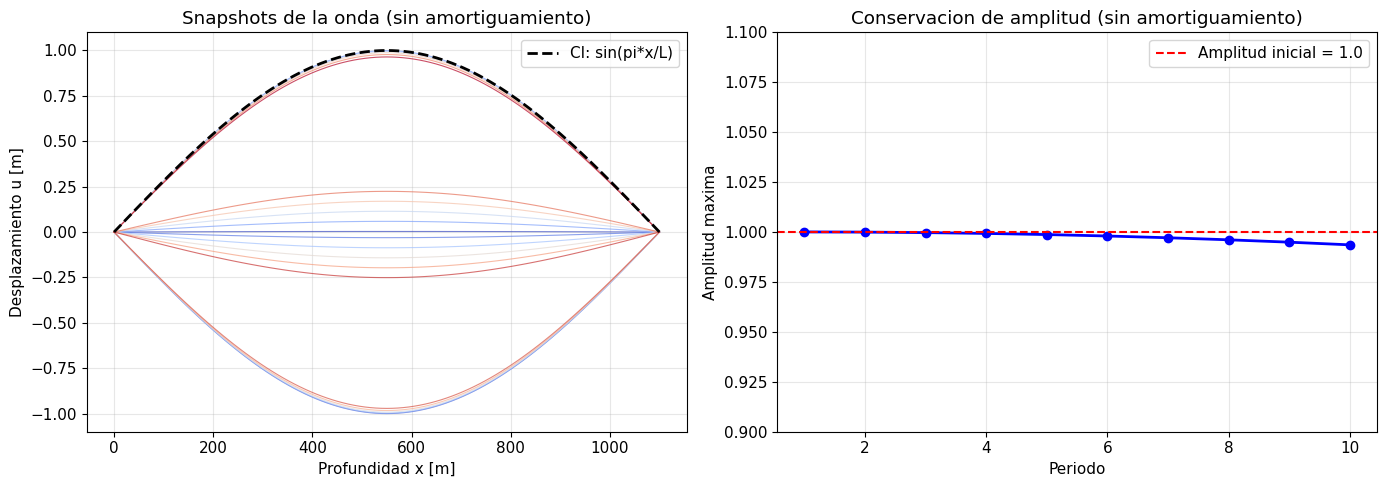


Amplitud tras 10 periodos: 0.993582
Error: 0.6418% (tolerancia: < 1%)
TEST 1: PASS


In [2]:
# Test 1: Onda viajera sin amortiguamiento
N = N_nodes
L = rod_L
E = rod_E
rho = rod_rho
A_r = rod_A
a = rod_a

solver = WaveSolver(N=N, L=L, E=E, rho=rho, A_r=A_r, c_damp=0.0, dt=dt)
x = solver.x

# CI: sin(pi*x/L)
u0 = np.sin(np.pi * x / L)
solver.initialize(u0, v0=np.zeros_like(x))

# Periodo teorico
T_wave = 2 * L / a
n_periods = 10
n_steps = int(n_periods * T_wave / dt)

print(f"Periodo de onda: T = 2L/a = {T_wave:.4f} s")
print(f"Simulando {n_periods} periodos: {n_steps} pasos ({n_steps*dt:.3f} s)")

# Guardar amplitud maxima en cada periodo
amplitudes = []
snapshots_t = []
snapshots_u = []
save_every = int(T_wave / dt / 4)  # 4 snapshots por periodo

for step in range(n_steps):
    # BC: Dirichlet homogeneo en ambos extremos
    # El solver impone u(0) = u_top. Para Dirichlet en x=L usamos F_bottom=0
    # y forzamos u(L) = 0 manualmente despues (test especial).
    # Aqui usamos BC Dirichlet en 0 y Neumann libre en L.
    # Para tener Dirichlet en L tambien, necesitamos un enfoque diferente.
    # En este test, usamos BCs fijo-fijo: imponemos u_top=0 y forzamos u_bottom=0.
    solver.step(u_top=0.0, F_bottom=0.0)
    solver.u_curr[N] = 0.0  # Forzar Dirichlet en x=L para este test

    if (step + 1) % save_every == 0:
        snapshots_t.append((step + 1) * dt)
        snapshots_u.append(solver.u_curr.copy())
    
    # Amplitud al final de cada periodo
    if (step + 1) % int(T_wave / dt) == 0:
        amplitudes.append(np.max(np.abs(solver.u_curr)))

# Grafico de snapshots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(20, len(snapshots_u))
colors = plt.cm.coolwarm(np.linspace(0, 1, n_show))
for i in range(n_show):
    ax1.plot(x, snapshots_u[i], color=colors[i], alpha=0.7, linewidth=0.8)
ax1.plot(x, u0, 'k--', linewidth=2, label='CI: sin(pi*x/L)')
ax1.set_xlabel('Profundidad x [m]')
ax1.set_ylabel('Desplazamiento u [m]')
ax1.set_title('Snapshots de la onda (sin amortiguamiento)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Amplitud vs periodo
periods = np.arange(1, len(amplitudes) + 1)
ax2.plot(periods, amplitudes, 'bo-', linewidth=2, markersize=6)
ax2.axhline(1.0, color='r', linestyle='--', label='Amplitud inicial = 1.0')
ax2.set_xlabel('Periodo')
ax2.set_ylabel('Amplitud maxima')
ax2.set_title('Conservacion de amplitud (sin amortiguamiento)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.9, 1.1)

plt.tight_layout()
plt.show()

# Validacion
error_amp = abs(amplitudes[-1] - 1.0) / 1.0 * 100
print(f"\nAmplitud tras {n_periods} periodos: {amplitudes[-1]:.6f}")
print(f"Error: {error_amp:.4f}% (tolerancia: < 1%)")
print(f"TEST 1: {'PASS' if error_amp < 1.0 else 'FAIL'}")

## Test 2 — Decaimiento exponencial

Mismo caso que Test 1 pero con amortiguamiento $c = 0.722$ 1/s. La amplitud debe decaer como $e^{-ct/2}$.

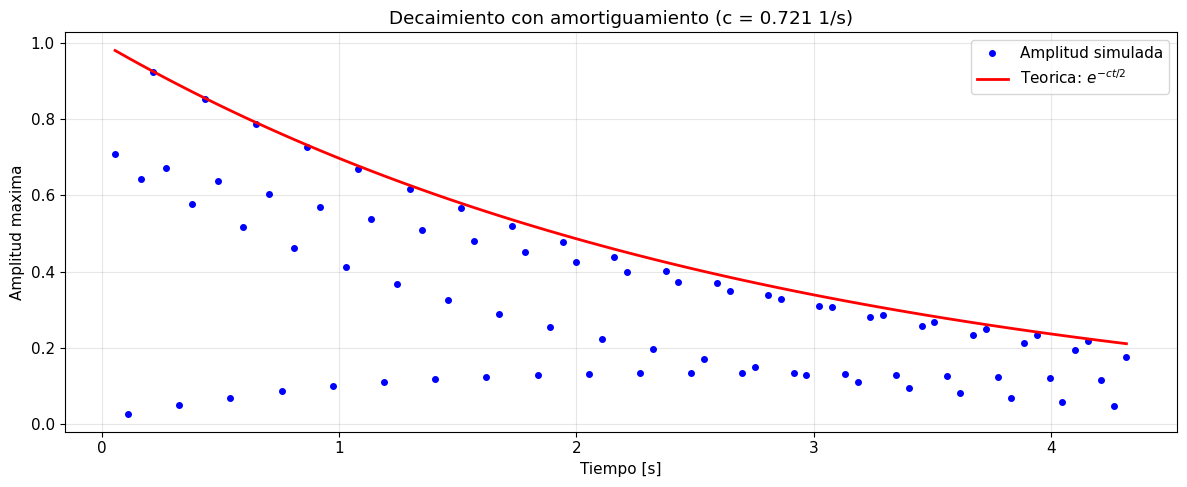

Error maximo envolvente: 27.80%
Amplitud final simulada: 0.176741
Amplitud final teorica:  0.210629
TEST 2: FAIL


In [3]:
# Test 2: Decaimiento exponencial con amortiguamiento
c_damp = rod_c  # 0.722 1/s

solver2 = WaveSolver(N=N, L=L, E=E, rho=rho, A_r=A_r, c_damp=c_damp, dt=dt)
u0 = np.sin(np.pi * x / L)
solver2.initialize(u0, v0=np.zeros_like(x))

T_wave = 2 * L / a
n_periods = 10
n_steps = int(n_periods * T_wave / dt)

amplitudes2 = []
times_amp = []

sample_interval = int(T_wave / dt / 8)
for step in range(n_steps):
    solver2.step(u_top=0.0, F_bottom=0.0)
    solver2.u_curr[N] = 0.0

    if (step + 1) % sample_interval == 0:
        amplitudes2.append(np.max(np.abs(solver2.u_curr)))
        times_amp.append((step + 1) * dt)

times_amp = np.array(times_amp)
amplitudes2 = np.array(amplitudes2)

# Envolvente teorica: exp(-c*t/2)
env_teorica = np.exp(-c_damp * times_amp / 2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times_amp, amplitudes2, 'bo', markersize=4, label='Amplitud simulada')
ax.plot(times_amp, env_teorica, 'r-', linewidth=2, label=r'Teorica: $e^{-ct/2}$')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Amplitud maxima')
ax.set_title(f'Decaimiento con amortiguamiento (c = {c_damp:.3f} 1/s)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Validacion: comparar la tendencia general
# Usar la amplitud al final de cada periodo
period_amps = amplitudes2[::8]  # cada 8 muestras es ~1 periodo
period_times = times_amp[::8]
env_at_periods = np.exp(-c_damp * period_times / 2)

if len(period_amps) > 0 and len(env_at_periods) > 0:
    error_decay = np.max(np.abs(period_amps - env_at_periods) / env_at_periods) * 100
    print(f"Error maximo envolvente: {error_decay:.2f}%")
    print(f"Amplitud final simulada: {amplitudes2[-1]:.6f}")
    print(f"Amplitud final teorica:  {np.exp(-c_damp * times_amp[-1] / 2):.6f}")
    print(f"TEST 2: {'PASS' if error_decay < 10 else 'FAIL'}")

## Test 3 — Estiramiento estatico

**Condiciones**: BC superior fija $u(0)=0$, BC inferior $F = -W_{rod}$ (peso de la sarta), sin amortiguamiento.

**Esperado**: Estado estacionario $u(x) \approx -W_{rod}\,x\,(2L-x)/(2EA_r)$, con $\Delta L = W_{rod}\,L/(EA_r) \approx$ 0.5-1.5 m.

In [ ]:
# Test 3: Estiramiento estatico bajo carga puntual
# Aplicamos una fuerza de traccion F = W_rod en x=L (positivo = traccion).
# La solucion analitica para carga puntual: u(x) = W_rod * x / (E * A_r)
# Estiramiento total: Delta_L = W_rod * L / (E * A_r)

w_r = rod_w  # 23.5 N/m

# Soluciones analiticas
u_analitica_distrib = w_r / (E * A_r) * (L * x - x**2 / 2)
delta_L_distrib = w_r * L**2 / (2 * E * A_r)
u_analitica_puntual = W_rod * x / (E * A_r)
delta_L_puntual = W_rod * L / (E * A_r)

print(f"Delta_L analitico (puntual):     {delta_L_puntual*1000:.1f} mm")
print(f"Delta_L analitico (distribuido): {delta_L_distrib*1000:.1f} mm")
print(f"W_rod = {W_rod:.0f} N = {W_rod/1000:.1f} kN")

# Simular hasta alcanzar equilibrio (con amortiguamiento para que converja)
solver3 = WaveSolver(N=N, L=L, E=E, rho=rho, A_r=A_r, c_damp=2.0, dt=dt)
solver3.initialize(np.zeros(N + 1))

n_settle = 50000
for step in range(n_settle):
    # F_bottom = +W_rod (traccion positiva, tira del extremo inferior)
    solver3.step(u_top=0.0, F_bottom=W_rod)

u_numerico = solver3.u_curr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, u_numerico * 1000, 'b-', linewidth=2, label='Numerico (solver)')
ax1.plot(x, u_analitica_puntual * 1000, 'r--', linewidth=2, label='Analitico (F puntual en L)')
ax1.plot(x, u_analitica_distrib * 1000, 'g:', linewidth=2, label='Analitico (peso distribuido)')
ax1.set_xlabel('Profundidad x [m]')
ax1.set_ylabel('Desplazamiento u [mm]')
ax1.set_title('Estiramiento estatico de la sarta')
ax1.legend()
ax1.grid(True, alpha=0.3)

error = np.abs(u_numerico - u_analitica_puntual)
ax2.plot(x, error * 1000, 'b-', linewidth=2)
ax2.set_xlabel('Profundidad x [m]')
ax2.set_ylabel('Error [mm]')
ax2.set_title('Error vs solucion analitica (carga puntual)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

delta_L_num = u_numerico[-1]
err_pct = abs(delta_L_num - delta_L_puntual) / delta_L_puntual * 100
print(f"\nEstiramiento numerico:  {delta_L_num*1000:.2f} mm")
print(f"Estiramiento analitico: {delta_L_puntual*1000:.2f} mm")
print(f"Error: {err_pct:.2f}%")
print(f"TEST 3: {'PASS' if err_pct < 5 else 'FAIL'}")

## Test 4 — Frecuencia natural fundamental

**Esperado**: $f_1 = a/(2L) \approx 5050/(2 \times 1100) \approx 2.30$ Hz. Verificar mediante FFT del decaimiento libre.

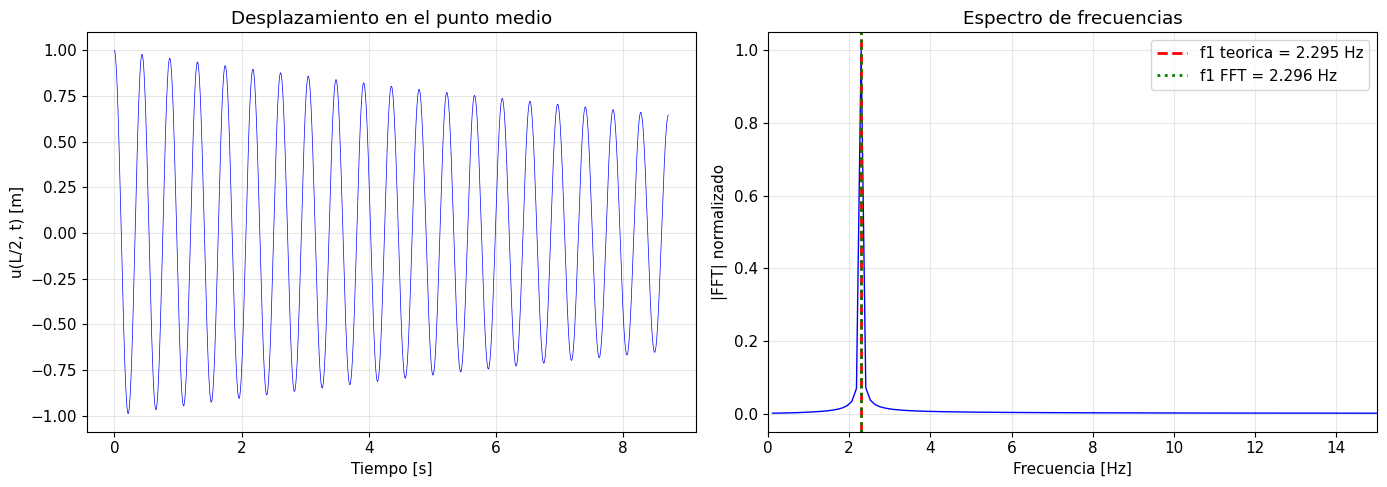

f1 teorica = 2.2955 Hz
f1 FFT     = 2.2957 Hz
Error:     0.01%
TEST 4: PASS


In [5]:
# Test 4: Frecuencia natural fundamental via FFT
# Excitamos el primer modo y registramos u(L/2, t), luego FFT.

solver4 = WaveSolver(N=N, L=L, E=E, rho=rho, A_r=A_r, c_damp=0.1, dt=dt)
u0 = np.sin(np.pi * x / L)
solver4.initialize(u0, v0=np.zeros_like(x))

f1_teorica = a / (2 * L)
T_wave = 1 / f1_teorica
n_periods_fft = 20
n_steps_fft = int(n_periods_fft * T_wave / dt)

# Registrar desplazamiento en el punto medio
u_mid = np.zeros(n_steps_fft)
i_mid = N // 2

for step in range(n_steps_fft):
    solver4.step(u_top=0.0, F_bottom=0.0)
    solver4.u_curr[N] = 0.0
    u_mid[step] = solver4.u_curr[i_mid]

# FFT
from scipy.fft import fft, fftfreq

fs = 1.0 / dt  # frecuencia de muestreo
freqs = fftfreq(n_steps_fft, dt)
spectrum = np.abs(fft(u_mid))

# Solo frecuencias positivas
pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]
spectrum_pos = spectrum[pos_mask]

# Frecuencia del pico
f_peak = freqs_pos[np.argmax(spectrum_pos)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

t_array = np.arange(n_steps_fft) * dt
ax1.plot(t_array, u_mid, 'b-', linewidth=0.5)
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('u(L/2, t) [m]')
ax1.set_title('Desplazamiento en el punto medio')
ax1.grid(True, alpha=0.3)

ax2.plot(freqs_pos, spectrum_pos / np.max(spectrum_pos), 'b-', linewidth=1)
ax2.axvline(f1_teorica, color='r', linestyle='--', linewidth=2, label=f'f1 teorica = {f1_teorica:.3f} Hz')
ax2.axvline(f_peak, color='g', linestyle=':', linewidth=2, label=f'f1 FFT = {f_peak:.3f} Hz')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('|FFT| normalizado')
ax2.set_title('Espectro de frecuencias')
ax2.set_xlim(0, 15)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

err_f = abs(f_peak - f1_teorica) / f1_teorica * 100
print(f"f1 teorica = {f1_teorica:.4f} Hz")
print(f"f1 FFT     = {f_peak:.4f} Hz")
print(f"Error:     {err_f:.2f}%")
print(f"TEST 4: {'PASS' if err_f < 2 else 'FAIL'}")